<a href="https://colab.research.google.com/github/caiohenry-jpg/CalculoNumerico/blob/main/atv_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Atividade prática III — Cálculo Numérico

**Estudante(s):** Preencha seu nome

## Critério de parada

Foi adotado o resíduo absoluto **|f(x)| < 1e-06**, com limite de
**100 iterações**. Uma iteração corresponde a uma nova aproximação;
os valores iniciais não são contados.

Um passo pequeno, sozinho, não garante que a função esteja próxima de zero.
Por isso, ele não é usado como condição suficiente de convergência.

Derivada ou denominador com módulo menor que **1e-12** interrompem o
método. Também são detectados valores não finitos, estagnação e limite
de iterações. Na bisseção, pressupõe-se que a função seja contínua
no intervalo e verifica-se a mudança de sinal nos extremos.


## Tabela de resultados

Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
f1(x) = x² - 2,Bisseção,"(1.0, 2.0)",1.4142136574,2.687e-07,21 / Convergiu
f1(x) = x² - 2,Newton,x0 = 1.5,1.4142135624,4.511e-12,3 / Convergiu
f1(x) = x² - 2,Secante,"(1.0, 2.0)",1.4142135621,8.931e-10,5 / Convergiu
f2(x) = x³ - x - 2,Bisseção,"(1.0, 2.0)",1.5213797092,1.450e-08,22 / Convergiu
f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.5213798060,5.894e-07,2 / Convergiu
f2(x) = x³ - x - 2,Secante,"(1.0, 2.0)",1.5213797080,7.015e-09,6 / Convergiu
f3(x) = exp(-x) - x,Bisseção,"(0.0, 1.0)",0.5671434402,2.348e-07,20 / Convergiu
f3(x) = exp(-x) - x,Newton,x0 = 0.5,0.5671431650,1.965e-07,2 / Convergiu
f3(x) = exp(-x) - x,Secante,"(0.0, 1.0)",0.5671433066,2.538e-08,4 / Convergiu
f4(x) = x³ - 2x + 2,Bisseção,"(-2.0, -1.0)",-1.7692923546,2.551e-09,21 / Convergiu


## Testes

Teste,Resultado
Bisseção — f1(x) = x² - 2,OK
Newton — f1(x) = x² - 2,OK
Secante — f1(x) = x² - 2,OK
Bisseção — f2(x) = x³ - x - 2,OK
Newton — f2(x) = x³ - x - 2,OK
Secante — f2(x) = x³ - x - 2,OK
Bisseção — f3(x) = exp(-x) - x,OK
Newton — f3(x) = exp(-x) - x,OK
Secante — f3(x) = exp(-x) - x,OK
Bisseção — f4(x) = x³ - 2x + 2,OK



## Análise dos resultados

Com os valores iniciais propostos e a tolerância de 10⁻⁶, os três métodos
convergem para as quatro funções. Em f1, o intervalo positivo seleciona
a raiz positiva; também existe a raiz negativa -√2.

Newton utiliza menos iterações nestes testes, mas exige o cálculo da
derivada. A secante usa dois pontos e dispensa a derivada. A bisseção
necessita de mais iterações, mas mantém um intervalo contendo uma raiz
quando a função é contínua e os extremos têm sinais opostos.

A escolha inicial influencia o comportamento: para f4, Newton com x0 = -2
converge, enquanto com x0 = 0 alterna entre 0 e 1. Nesse caso,
f4(0) = 2, f4'(0) = -2, f4(1) = 1 e f4'(1) = 1.
O método chega ao limite de iterações sem convergir.

O resíduo mede quanto f(x) se aproxima de zero; em geral, ele não é
um limite direto para o erro na raiz. As contagens dependem do critério
de parada, por isso os resultados da tabela são calculados pelo código.


## Animações

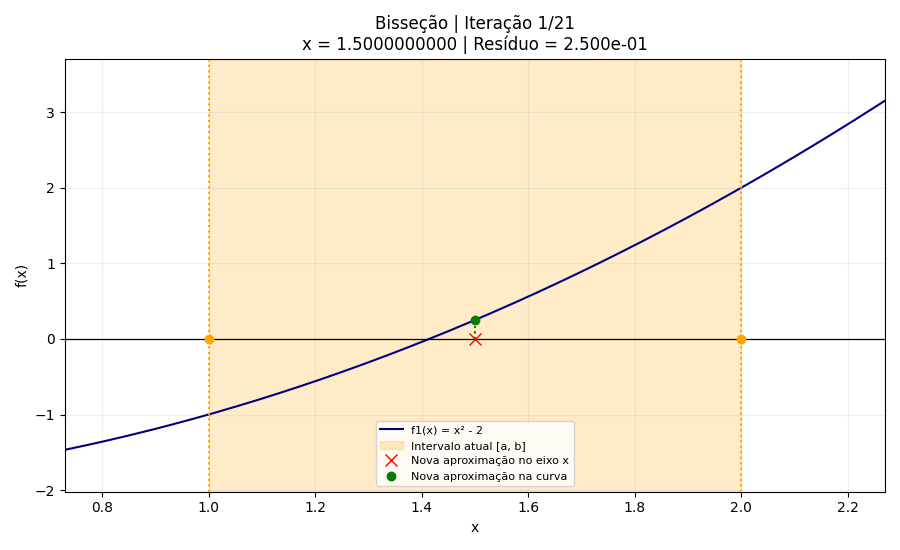

GIF salvo: resultados_atividade_3/bissecao_f1.gif


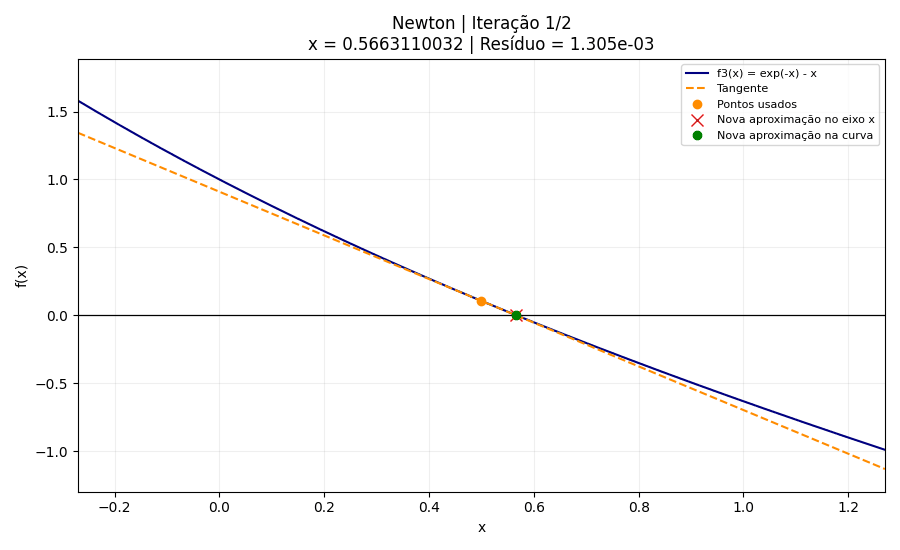

GIF salvo: resultados_atividade_3/newton_f3.gif


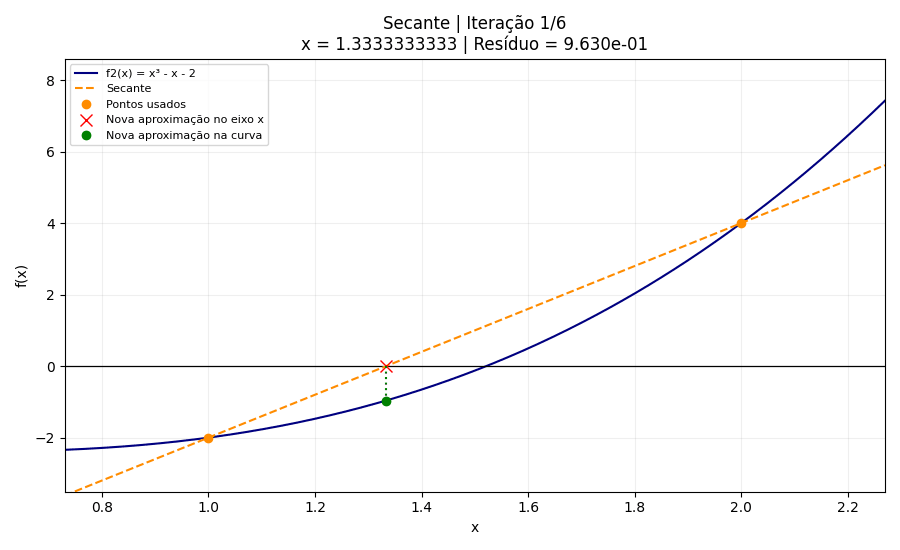

GIF salvo: resultados_atividade_3/secante_f2.gif





O ZIP contém os três GIFs, a tabela em CSV, HTML e PNG, os testes e a análise.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ATIVIDADE PRÁTICA III — CÁLCULO NUMÉRICO
# Caio Hênry - 180374

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Markdown, HTML, Image
from pathlib import Path
import zipfile

# 1. CONFIGURAÇÕES


NOME = "Preencha seu nome"
TOL = 1e-6
MAX_ITER = 100
EPS = 1e-12

PASTA = Path("resultados_atividade_3")
PASTA.mkdir(exist_ok=True)

# Critério de parada: |f(x)| < TOL.
# Cada iteração corresponde a uma nova aproximação calculada.
# Os valores iniciais não são contados como iterações.
#
# Retorno dos métodos:
# (raiz, número de iterações, aproximações, status, dados da animação)


def avaliar(f, x):
    try:
        with np.errstate(all="ignore"):
            valor = float(f(x))
        return valor if np.isfinite(valor) else np.nan
    except (ArithmeticError, ValueError):
        return np.nan


def validar(tol, max_iter):
    if not np.isfinite(tol) or tol <= 0:
        raise ValueError("A tolerância deve ser positiva e finita.")
    if not isinstance(max_iter, int) or max_iter < 1:
        raise ValueError("max_iter deve ser um inteiro positivo.")


def retorno(x, historico, status, passos):
    return x, len(historico), historico, status, passos


# 2. MÉTODO DA BISSEÇÃO

def bissecao(f, a, b, tol=1e-6, max_iter=100):
    validar(tol, max_iter)
    historico, passos = [], []

    if not np.isfinite([a, b]).all() or a >= b:
        return retorno(None, historico, "Falha: intervalo inválido", passos)

    fa, fb = avaliar(f, a), avaliar(f, b)

    if not np.isfinite([fa, fb]).all():
        return retorno(None, historico, "Falha: valor não finito", passos)

    for x, fx in [(a, fa), (b, fb)]:
        if abs(fx) < tol:
            return retorno(x, historico, "Convergiu", passos)

    if np.sign(fa) == np.sign(fb):
        return retorno(
            None, historico, "Falha: extremos com o mesmo sinal", passos
        )

    for _ in range(max_iter):
        c = a + (b - a) / 2
        fc = avaliar(f, c)

        if not np.isfinite(fc):
            return retorno(c, historico, "Falha: valor não finito", passos)

        historico.append(c)
        passos.append({"a": a, "b": b, "x": c, "fx": fc})

        if abs(fc) < tol:
            return retorno(c, historico, "Convergiu", passos)

        if c == a or c == b:
            return retorno(c, historico, "Falha: estagnação numérica", passos)

        if np.sign(fa) != np.sign(fc):
            b, fb = c, fc
        else:
            a, fa = c, fc

    return retorno(c, historico, "Falha: limite de iterações", passos)


# 3. MÉTODO DE NEWTON

def newton(f, df, x0, tol=1e-6, max_iter=100):
    validar(tol, max_iter)
    historico, passos = [], []
    x = float(x0)

    for _ in range(max_iter):
        fx = avaliar(f, x)

        if not np.isfinite([x, fx]).all():
            return retorno(x, historico, "Falha: valor não finito", passos)

        if abs(fx) < tol:
            return retorno(x, historico, "Convergiu", passos)

        dfx = avaliar(df, x)

        if not np.isfinite(dfx) or abs(dfx) < EPS:
            return retorno(
                x, historico,
                "Falha: derivada nula, próxima de zero ou inválida",
                passos
            )

        novo = x - fx / dfx
        fnovo = avaliar(f, novo)

        if not np.isfinite([novo, fnovo]).all():
            return retorno(x, historico, "Falha: valor não finito", passos)

        historico.append(novo)
        passos.append({
            "anterior": x,
            "f_anterior": fx,
            "inclinacao": dfx,
            "x": novo,
            "fx": fnovo
        })

        if abs(fnovo) < tol:
            return retorno(novo, historico, "Convergiu", passos)

        if novo == x:
            return retorno(
                novo, historico, "Falha: estagnação numérica", passos
            )

        x = novo

    return retorno(x, historico, "Falha: limite de iterações", passos)


# 4. MÉTODO DA SECANTE

def secante(f, x0, x1, tol=1e-6, max_iter=100):
    validar(tol, max_iter)
    historico, passos = [], []

    x0, x1 = float(x0), float(x1)
    f0, f1 = avaliar(f, x0), avaliar(f, x1)

    if not np.isfinite([x0, x1, f0, f1]).all():
        return retorno(None, historico, "Falha: valor não finito", passos)

    for x, fx in [(x0, f0), (x1, f1)]:
        if abs(fx) < tol:
            return retorno(x, historico, "Convergiu", passos)

    for _ in range(max_iter):
        denominador = f1 - f0

        if not np.isfinite(denominador) or abs(denominador) < EPS:
            return retorno(
                x1, historico,
                "Falha: denominador nulo, próximo de zero ou inválido",
                passos
            )

        novo = x1 - f1 * (x1 - x0) / denominador
        fnovo = avaliar(f, novo)

        if not np.isfinite([novo, fnovo]).all():
            return retorno(x1, historico, "Falha: valor não finito", passos)

        historico.append(novo)
        passos.append({
            "x0": x0,
            "f0": f0,
            "anterior": x1,
            "f_anterior": f1,
            "inclinacao": denominador / (x1 - x0),
            "x": novo,
            "fx": fnovo
        })

        if abs(fnovo) < tol:
            return retorno(novo, historico, "Convergiu", passos)

        if novo == x1:
            return retorno(
                novo, historico, "Falha: estagnação numérica", passos
            )

        x0, f0, x1, f1 = x1, f1, novo, fnovo

    return retorno(x1, historico, "Falha: limite de iterações", passos)


# ============================================================
# 5. FUNÇÕES E VALORES INICIAIS
# ============================================================

FUNCOES = [
    {
        "nome": "f1(x) = x² - 2",
        "f": lambda x: x**2 - 2,
        "df": lambda x: 2*x,
        "intervalo": (1.0, 2.0),
        "x0": 1.5,
        "secante": (1.0, 2.0),
        "dominio": (0.8, 2.2)
    },
    {
        "nome": "f2(x) = x³ - x - 2",
        "f": lambda x: x**3 - x - 2,
        "df": lambda x: 3*x**2 - 1,
        "intervalo": (1.0, 2.0),
        "x0": 1.5,
        "secante": (1.0, 2.0),
        "dominio": (0.8, 2.2)
    },
    {
        "nome": "f3(x) = exp(-x) - x",
        "f": lambda x: np.exp(-x) - x,
        "df": lambda x: -np.exp(-x) - 1,
        "intervalo": (0.0, 1.0),
        "x0": 0.5,
        "secante": (0.0, 1.0),
        "dominio": (-0.2, 1.2)
    },
    {
        "nome": "f4(x) = x³ - 2x + 2",
        "f": lambda x: x**3 - 2*x + 2,
        "df": lambda x: 3*x**2 - 2,
        "intervalo": (-2.0, -1.0),
        "x0": -2.0,
        "secante": (-2.0, -1.0),
        "dominio": (-2.2, -0.8)
    }
]

display(Markdown(f"""
# Atividade prática III — Cálculo Numérico

**Estudante(s):** {NOME}

## Critério de parada

Foi adotado o resíduo absoluto **|f(x)| < {TOL}**, com limite de
**{MAX_ITER} iterações**. Uma iteração corresponde a uma nova aproximação;
os valores iniciais não são contados.

Um passo pequeno, sozinho, não garante que a função esteja próxima de zero.
Por isso, ele não é usado como condição suficiente de convergência.

Derivada ou denominador com módulo menor que **{EPS}** interrompem o
método. Também são detectados valores não finitos, estagnação e limite
de iterações. Na bisseção, pressupõe-se que a função seja contínua
no intervalo e verifica-se a mudança de sinal nos extremos.
"""))


# ============================================================
# 6. TABELA DOS RESULTADOS
# ============================================================

linhas = []
resultados = {}

for indice, item in enumerate(FUNCOES):
    f, df = item["f"], item["df"]

    casos = [
        (
            "Bisseção",
            str(item["intervalo"]),
            bissecao(f, *item["intervalo"], TOL, MAX_ITER)
        ),
        (
            "Newton",
            f"x0 = {item['x0']}",
            newton(f, df, item["x0"], TOL, MAX_ITER)
        ),
        (
            "Secante",
            str(item["secante"]),
            secante(f, *item["secante"], TOL, MAX_ITER)
        )
    ]

    for metodo, iniciais, resultado in casos:
        raiz, n, historico, status, passos = resultado
        resultados[indice, metodo] = resultado

        linhas.append({
            "Função": item["nome"],
            "Método": metodo,
            "Valores iniciais": iniciais,
            "Raiz aproximada": raiz,
            "|f(x)| final": (
                abs(avaliar(f, raiz)) if raiz is not None else np.nan
            ),
            "Iterações/resultado": f"{n} / {status}"
        })

tabela = pd.DataFrame(linhas)

formatadores = {
    "Raiz aproximada": lambda x: f"{x:.10f}",
    "|f(x)| final": lambda x: f"{x:.3e}"
}

display(Markdown("## Tabela de resultados"))
display(HTML(tabela.to_html(index=False, formatters=formatadores)))

tabela.to_csv(
    PASTA / "tabela_resultados.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela.to_html(
    PASTA / "tabela_resultados.html",
    index=False,
    formatters=formatadores
)


# 7. TESTES DE CONVERGÊNCIA E DE FALHA

testes = []

for (indice, metodo), resultado in resultados.items():
    raiz, n, historico, status, passos = resultado

    correto = (
        status == "Convergiu"
        and abs(FUNCOES[indice]["f"](raiz)) < TOL
        and n == len(historico) == len(passos)
    )

    testes.append({
        "Teste": f"{metodo} — {FUNCOES[indice]['nome']}",
        "Resultado": "OK" if correto else "REVISAR"
    })

casos_falha = [
    (
        "Bisseção: extremos sem mudança de sinal",
        bissecao(lambda x: x*x + 1, -1, 1)
    ),
    (
        "Newton: derivada nula",
        newton(lambda x: x*x + 1, lambda x: 2*x, 0)
    ),
    (
        "Newton: derivada próxima de zero",
        newton(lambda x: x*x + 1, lambda x: 1e-14, 1)
    ),
    (
        "Secante: denominador nulo",
        secante(lambda x: x*x + 1, -1, 1)
    ),
    (
        "Secante: denominador próximo de zero",
        secante(lambda x: 1 + 1e-14*x, 0, 1)
    ),
    (
        "Bisseção: limite de iterações",
        bissecao(FUNCOES[0]["f"], 1, 2, TOL, 1)
    ),
    (
        "Secante: limite de iterações",
        secante(FUNCOES[0]["f"], 1, 2, TOL, 1)
    )
]

ciclo = newton(
    FUNCOES[3]["f"], FUNCOES[3]["df"], 0, TOL, MAX_ITER
)

casos_falha.append(("Newton em f4 com x0 = 0: ciclo 0 → 1 → 0", ciclo))

for nome, resultado in casos_falha:
    testes.append({
        "Teste": nome,
        "Resultado": (
            "OK: " + resultado[3]
            if resultado[3].startswith("Falha")
            else "REVISAR"
        )
    })

display(Markdown("## Testes"))
tabela_testes = pd.DataFrame(testes)
display(HTML(tabela_testes.to_html(index=False)))

tabela_testes.to_csv(
    PASTA / "testes.csv", index=False, encoding="utf-8-sig"
)



# 8. ANÁLISE

analise = """
## Análise dos resultados

Com os valores iniciais propostos e a tolerância de 10⁻⁶, os três métodos
convergem para as quatro funções. Em f1, o intervalo positivo seleciona
a raiz positiva; também existe a raiz negativa -√2.

Newton utiliza menos iterações nestes testes, mas exige o cálculo da
derivada. A secante usa dois pontos e dispensa a derivada. A bisseção
necessita de mais iterações, mas mantém um intervalo contendo uma raiz
quando a função é contínua e os extremos têm sinais opostos.

A escolha inicial influencia o comportamento: para f4, Newton com x0 = -2
converge, enquanto com x0 = 0 alterna entre 0 e 1. Nesse caso,
f4(0) = 2, f4'(0) = -2, f4(1) = 1 e f4'(1) = 1.
O método chega ao limite de iterações sem convergir.

O resíduo mede quanto f(x) se aproxima de zero; em geral, ele não é
um limite direto para o erro na raiz. As contagens dependem do critério
de parada, por isso os resultados da tabela são calculados pelo código.
"""

display(Markdown(analise))
(PASTA / "analise.txt").write_text(analise, encoding="utf-8")



# 9. ANIMAÇÕES E EXPORTAÇÃO DOS GIFS

def criar_gif(indice, metodo, nome_arquivo):
    item = FUNCOES[indice]
    passos = resultados[indice, metodo][4]

    if not passos:
        print(f"Sem passos para animar: {metodo} — {item['nome']}")
        return

    # Ajusta o domínio para incluir os pontos usados no método.
    pontos = list(item["dominio"])

    for passo in passos:
        pontos.extend(
            passo[chave]
            for chave in ("x", "anterior", "x0", "a", "b")
            if chave in passo
        )

    margem = 0.05 * max(max(pontos) - min(pontos), 1)
    limites = (min(pontos) - margem, max(pontos) + margem)

    xx = np.linspace(*limites, 500)
    yy = item["f"](xx)

    ymin = min(float(yy.min()), 0)
    ymax = max(float(yy.max()), 0)
    margem_y = 0.12 * max(ymax - ymin, 1)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    def atualizar(frame):
        ax.clear()
        passo = passos[frame]

        ax.plot(xx, yy, color="navy", label=item["nome"])
        ax.axhline(0, color="black", linewidth=0.9)

        if metodo == "Bisseção":
            a, b = passo["a"], passo["b"]

            ax.axvspan(
                a, b, color="orange", alpha=0.22,
                label="Intervalo atual [a, b]"
            )
            ax.axvline(a, color="orange", linestyle=":")
            ax.axvline(b, color="orange", linestyle=":")
            ax.plot([a, b], [0, 0], "o", color="orange")

        else:
            reta = (
                passo["f_anterior"]
                + passo["inclinacao"] * (xx - passo["anterior"])
            )

            ax.plot(
                xx, reta, "--", color="darkorange",
                label="Tangente" if metodo == "Newton" else "Secante"
            )

            usados = (
                [passo["anterior"]]
                if metodo == "Newton"
                else [passo["x0"], passo["anterior"]]
            )

            ax.plot(
                usados,
                [item["f"](x) for x in usados],
                "o", color="darkorange", label="Pontos usados"
            )

        ax.plot(
            passo["x"], 0, "x", color="red", markersize=9,
            label="Nova aproximação no eixo x"
        )
        ax.plot(
            passo["x"], passo["fx"], "o", color="green",
            label="Nova aproximação na curva"
        )
        ax.plot(
            [passo["x"], passo["x"]],
            [0, passo["fx"]],
            ":", color="green"
        )

        ax.set(
            xlim=limites,
            ylim=(ymin - margem_y, ymax + margem_y),
            xlabel="x",
            ylabel="f(x)",
            title=(
                f"{metodo} | Iteração {frame + 1}/{len(passos)}\n"
                f"x = {passo['x']:.10f} | "
                f"Resíduo = {abs(passo['fx']):.3e}"
            )
        )

        ax.grid(alpha=0.2)
        ax.legend(loc="best", fontsize=8)
        fig.tight_layout()

    animacao = FuncAnimation(
        fig, atualizar, frames=len(passos), interval=1000, repeat=True
    )

    destino = PASTA / nome_arquivo
    animacao.save(str(destino), writer=PillowWriter(fps=1), dpi=100)
    plt.close(fig)

    display(Image(filename=str(destino)))
    print("GIF salvo:", destino)


display(Markdown("## Animações"))

criar_gif(0, "Bisseção", "bissecao_f1.gif")
criar_gif(2, "Newton", "newton_f3.gif")
criar_gif(1, "Secante", "secante_f2.gif")


# 10. EXPORTAÇÃO DA TABELA COMO IMAGEM

visual = tabela.copy()

visual["Raiz aproximada"] = visual["Raiz aproximada"].map(
    lambda x: f"{x:.10f}"
)
visual["|f(x)| final"] = visual["|f(x)| final"].map(
    lambda x: f"{x:.3e}"
)

fig, ax = plt.subplots(figsize=(17, 6))
ax.axis("off")

tabela_imagem = ax.table(
    cellText=visual.values,
    colLabels=visual.columns,
    loc="center",
    cellLoc="center"
)

tabela_imagem.auto_set_font_size(False)
tabela_imagem.set_fontsize(9)
tabela_imagem.scale(1, 2)
tabela_imagem.auto_set_column_width(
    col=list(range(len(visual.columns)))
)

fig.savefig(
    PASTA / "tabela_resultados.png",
    dpi=170,
    bbox_inches="tight"
)
plt.close(fig)



# 11. ZIP E DOWNLOAD


arquivo_zip = Path("entrega_atividade_3.zip")

arquivos = [
    "bissecao_f1.gif",
    "newton_f3.gif",
    "secante_f2.gif",
    "tabela_resultados.csv",
    "tabela_resultados.html",
    "tabela_resultados.png",
    "testes.csv",
    "analise.txt"
]

with zipfile.ZipFile(
    arquivo_zip, "w", compression=zipfile.ZIP_DEFLATED
) as zip_saida:
    for nome in arquivos:
        caminho = PASTA / nome
        if caminho.exists():
            zip_saida.write(caminho, arcname=nome)

display(Markdown("""


O ZIP contém os três GIFs, a tabela em CSV, HTML e PNG, os testes e a análise.

"""))

from google.colab import files
files.download(str(arquivo_zip))